In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/results/outlines_data_results.csv')

df['ShortFile'] = df['File'].str.replace('.csv', '', regex=False)

metric_cols = ['Accuracy','Recall (macro)']

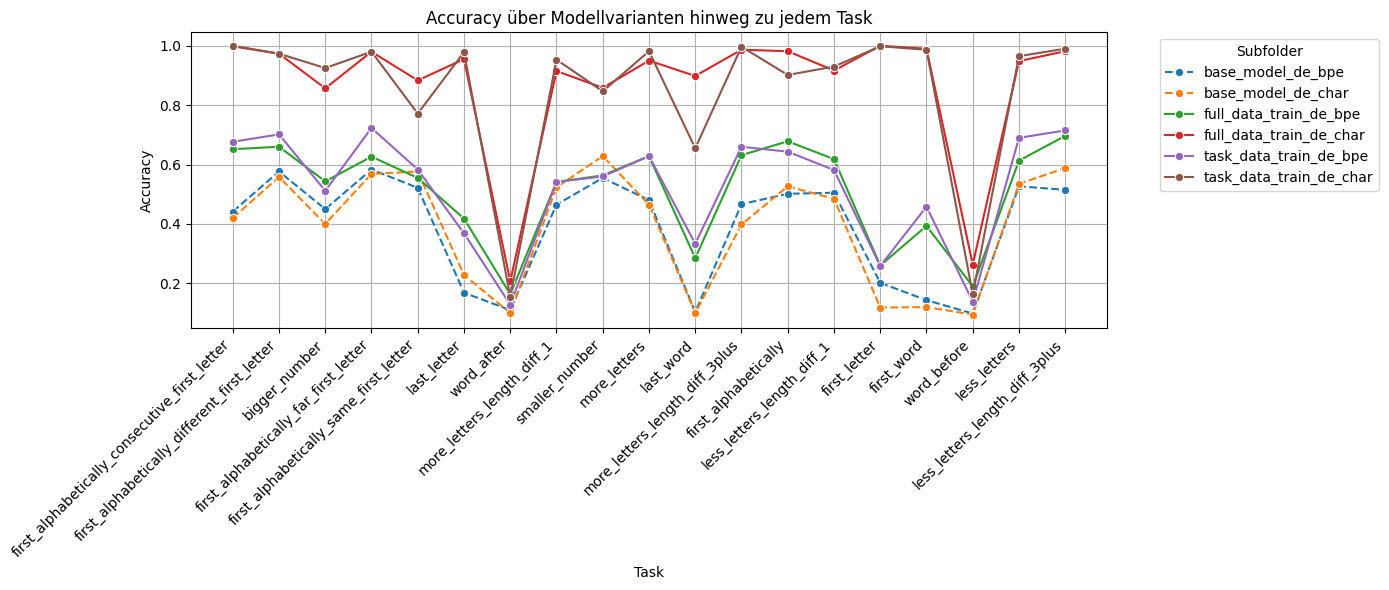

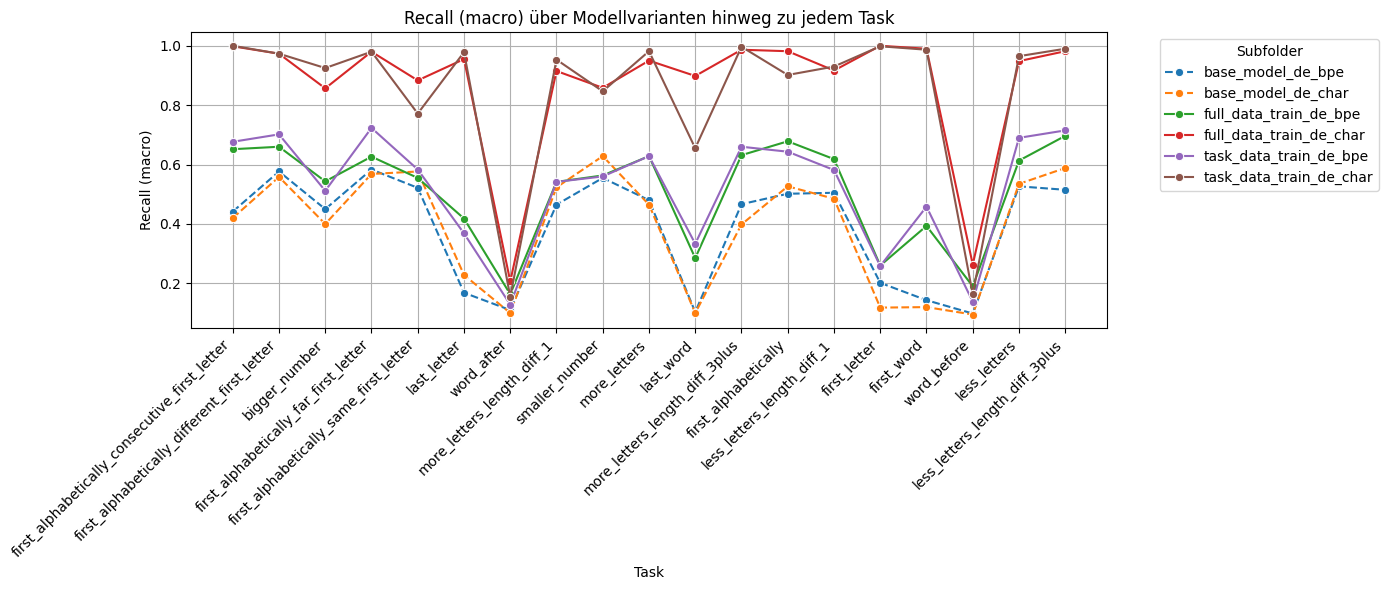

In [11]:
melted = df.melt(id_vars=['ShortFile', 'Subfolder'], 
                 value_vars=metric_cols,
                 var_name='Metrik', 
                 value_name='Wert')

metrics = ['Accuracy','Recall (macro)']

melted_de = melted[melted['Subfolder'].str.contains('_de', na=False)]

for metric in metrics:
    subset = melted_de[melted_de['Metrik'] == metric]
    
    plt.figure(figsize=(14, 6))
    
    # Subfolder durchgehen und jeweils plotten
    for subfolder, data in subset.groupby("Subfolder"):
        linestyle = "--" if subfolder.startswith("base_") else "-"
        sns.lineplot(
            data=data,
            x="ShortFile",
            y="Wert",
            label=subfolder,
            marker="o",
            linestyle=linestyle
        )
    
    plt.xlabel("Task")
    plt.ylabel(metric) 
    plt.title(f"{metric} über Modellvarianten hinweg zu jedem Task")
    plt.legend(title="Subfolder", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)  # Gitter hinzufügen
    plt.tight_layout()
    plt.show()


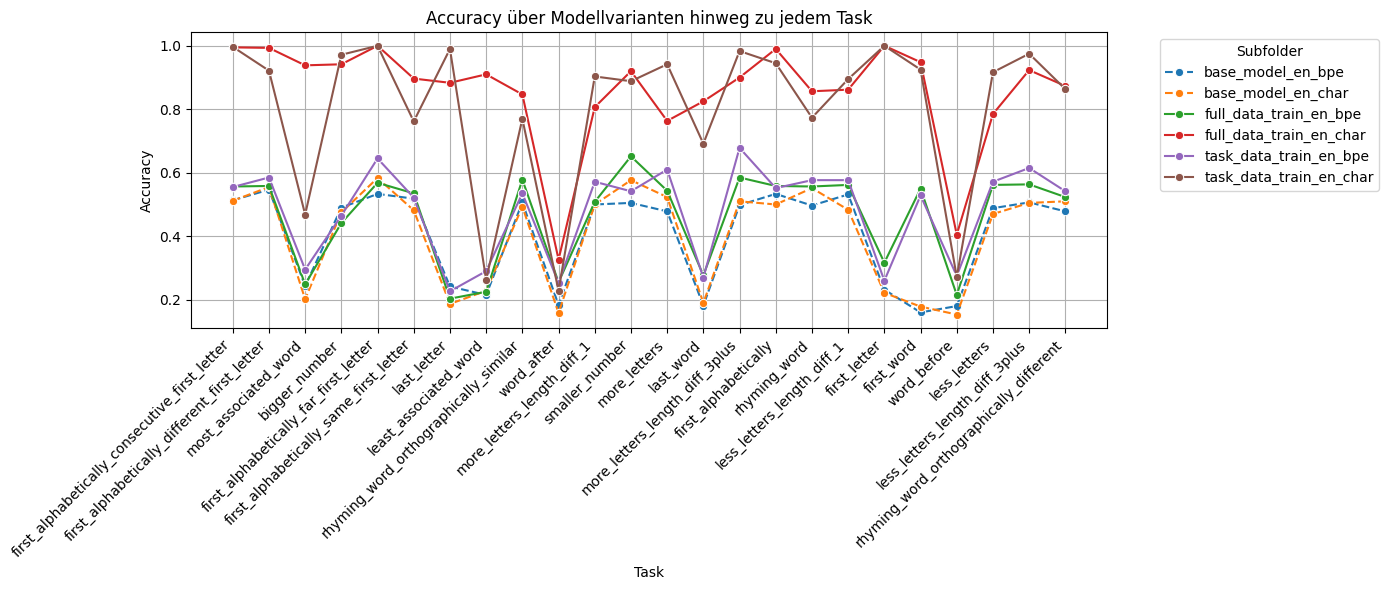

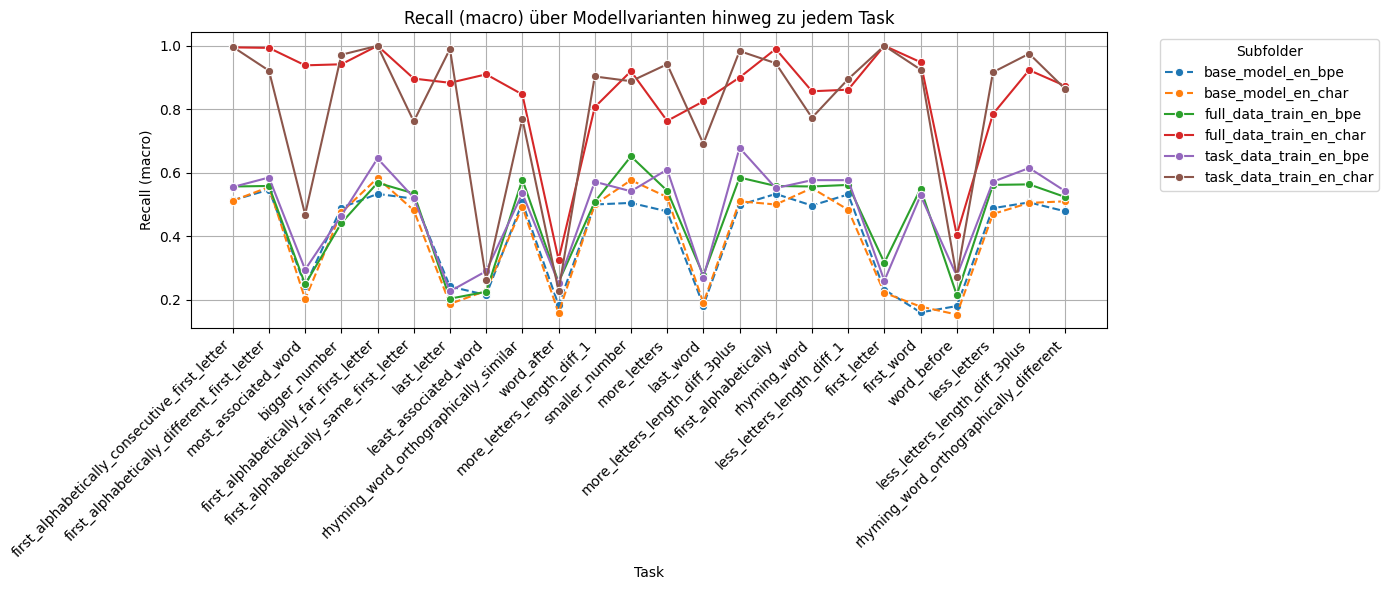

In [10]:
melted_en = melted[melted['Subfolder'].str.contains('_en', na=False)]

for metric in metrics:
    subset = melted_en[melted_en['Metrik'] == metric]
    
    plt.figure(figsize=(14, 6))
    
    # Subfolder durchgehen und jeweils plotten
    for subfolder, data in subset.groupby("Subfolder"):
        linestyle = "--" if subfolder.startswith("base_") else "-"
        sns.lineplot(
            data=data,
            x="ShortFile",
            y="Wert",
            label=subfolder,
            marker="o",
            linestyle=linestyle
        )
    
    plt.xlabel("Task")
    plt.ylabel(metric) 
    plt.title(f"{metric} über Modellvarianten hinweg zu jedem Task")
    plt.legend(title="Subfolder", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)  # Gitter hinzufügen
    plt.tight_layout()
    plt.show()
